In [12]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [8]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes : int
    
    strike_rate: float
    balls_per_boundary: float
    boundary_percentage: float
    summary: str

In PARALLEL WORKFLOWS, we don't need to return the entire state everytime from the Nodes. It creates error when we try to compile the graph and print the result. 

So even though we aren't changing any field inside the state lets suppose in below function, we aren't even changing the values for "runs" and "balls" but we're still returning the entire state, so during compilate Langgraph feels like all the states have been changed and from the parallel flows when it recives all those changed state for every field which it never expected, it leads to error

So yeah that's that, only return the field(s) whose value has been chanaged and leave the rest as it is

This is NOT the case in SEQUENTIAL WORKFLOWS

In [25]:
def calculate_strike_rate(state: BatsmanState) -> dict:
    
    runs, balls = state['runs'], state['balls']
    
    strike_rate = (runs / balls) * 100 if balls != 0 else 0.0
    
    
    return {
        "strike_rate": strike_rate
    }

In [27]:
def calculate_balls_per_boundary(state: BatsmanState) -> dict:
    
    balls, fours, sixes = state['balls'], state['fours'], state['sixes']

    
    total_boundaries = fours + sixes
    balls_per_boundary = balls / total_boundaries if total_boundaries != 0 else 0.0
    
    
    return {
        "balls_per_boundary": balls_per_boundary
    }

In [28]:
def calculate_boundary_percent(state: BatsmanState) -> dict:
    
    runs, fours, sixes = state['runs'], state['fours'], state['sixes']

    
    boundary_runs = (fours * 4) + (sixes * 6)
    boundary_percent = (boundary_runs / runs) * 100 if runs != 0 else 0.0
        
    return {
        "boundary_percentage": boundary_percent
    }

In [29]:
def summary(state: BatsmanState) -> dict:
    
    summary = f"""
    Strike Rate - {state['strike_rate']} \n
    Balls Per Boundary - {state['balls_per_boundary']} \n
    Boundary percent - {state['boundary_percentage']}
    """
    
    
    state['summary'] = summary
    
    return {
        "summary": summary
    }

In [30]:
graph = StateGraph(BatsmanState)

# Nodes
graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_balls_per_boundary', calculate_balls_per_boundary)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)


# Edges
graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_balls_per_boundary')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_strike_rate', 'summary')
graph.add_edge('calculate_balls_per_boundary', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)


workflow = graph.compile()

PARALLEL WORKFLOW

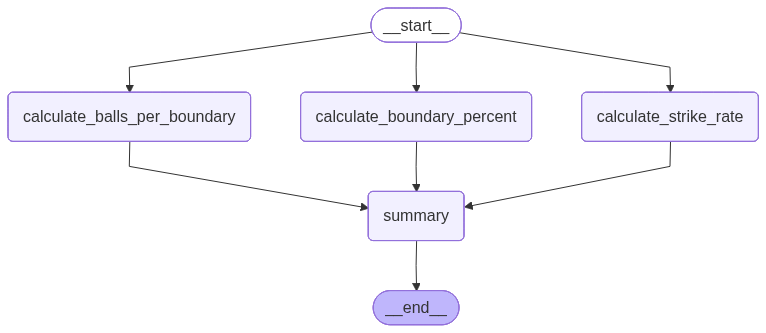

In [31]:
workflow

In [32]:
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'strike_rate': 200.0,
 'balls_per_boundary': 5.0,
 'boundary_percentage': 48.0,
 'summary': '\n    Strike Rate - 200.0 \n\n    Balls Per Boundary - 5.0 \n\n    Boundary percent - 48.0\n    '}